In [1]:
# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
# --- 参数配置 ---

# Mirror-AE
# vae_config_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp007-aediff-16.yaml"
# vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mirror-exp001-aediff-16/checkpoints/0040000.pt"
# sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mirror-000-SiT-B-1-linear-uniform-0040000.pt/checkpoints/0120000.pt"
# vq_mean = 0.23553907839716345
# vq_std = 1.356034517288208

# Mirror-JEPAAE
# vae_config_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp006-aejepadiff-16.yaml"
# vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mirror-exp000-aejepadiff-16-jepa1.0-blocktyperandom/checkpoints/0040000.pt"
# sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mirror-000-SiT-B-1-linear-uniform-0040000.pt-jepa1.0-blocktyperandom/checkpoints/0120000.pt"
# vq_mean = 0.2519823589246126 
# vq_std = 1.5136642456054688

# Minst-Mnist-JEPAAE
vae_config_path =  "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp006-aejepadiff-16.yaml"
vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp004-aejepadiff-16-jepa1.0-blocktyperandom/checkpoints/0001500.pt"
sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mnist-mnist-seq-000-SiT-B-1-linear-uniform-0001500.pt-jepa1.0-blocktyperandom/checkpoints/0062000.pt"
vq_mean = 0.24468633210659027 
vq_std = 1.3076791763305664

# Minst-Mnist-AE
# vae_config_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp007-aediff-16.yaml"
# vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp003-aediff-16/checkpoints/0001500.pt"
# sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mnist-mnist-seq-000-SiT-B-1-linear-uniform-0001500.pt/checkpoints/0062000.pt"
# vq_mean = 0.07790039056539536
# vq_std = 0.9384990930557251

model_name = "SiT-B/1"
num_classes =  1 #3
resolution = 64
path_type = "linear"
cfg_scale = 4.0
num_steps = 20
guidance_low = 0.0
guidance_high = 0.7

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")


block_kwargs = {"fused_attn": False, "flash_attn": True, "qk_norm": False}
model = SiT_models[model_name](
    in_channels=vae_embed_dim,
    input_size=dit_input_size,
    num_classes=num_classes,
    use_cfg=True,
    z_dims=[0],
    vae_1d=vae_1d,
    **block_kwargs,
)
state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']
model.load_state_dict(state_dict, strict=False)
model = model.to(device).eval()
print("Loaded SiT model.")

from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

# mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

processor = AutoProcessor.from_pretrained(local_path)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-16 21:25:32.709370: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 21:25:32.723207: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744809932.739498 1877528 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744809932.744123 1877528 cuda_blas.cc:1407] Un

Using device: cuda:1
<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False


/tmp/ipykernel_1877528/3967391313.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']


Loaded SiT model.


Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  1.72it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [2]:
with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")

<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False


In [3]:
def euler_sampler(
        model,
        latents,
        y,
        num_steps=20,
        heun=False,
        cfg_scale=1.0,
        guidance_low=0.0,
        guidance_high=1.0,
        path_type="linear", # not used, just for compatability
        num_classes=1000,
        ):
    # setup conditioning
    if cfg_scale > 1.0:
        y_null = torch.tensor([num_classes] * y.size(0), device=y.device)
    _dtype = latents.dtype    
    t_steps = torch.linspace(1, 0, num_steps+1, dtype=torch.float64)
    x_next = latents.to(torch.float64)
    device = x_next.device

    with torch.no_grad():
        for i, (t_cur, t_next) in enumerate(zip(t_steps[:-1], t_steps[1:])):
            x_cur = x_next
            if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                model_input = torch.cat([x_cur] * 2, dim=0)
                y_cur = torch.cat([y, y_null], dim=0)
            else:
                model_input = x_cur
                y_cur = y            
            kwargs = dict(y=y_cur)
            time_input = torch.ones(model_input.size(0)).to(device=device, dtype=torch.float64) * t_cur
            d_cur = model(
                model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
                )[0].to(torch.float64)
            # print("d_curL",d_cur.shape)
            if cfg_scale > 1. and t_cur <= guidance_high and t_cur >= guidance_low:
                d_cur_cond, d_cur_uncond = d_cur.chunk(2)
                d_cur = d_cur_uncond + cfg_scale * (d_cur_cond - d_cur_uncond)                
            x_next = x_cur + (t_next - t_cur) * d_cur
            if heun and (i < num_steps - 1):
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    model_input = torch.cat([x_next] * 2)
                    y_cur = torch.cat([y, y_null], dim=0)
                else:
                    model_input = x_next
                    y_cur = y
                kwargs = dict(y=y_cur)
                time_input = torch.ones(model_input.size(0)).to(
                    device=model_input.device, dtype=torch.float64
                    ) * t_next
                d_prime = model(
                    model_input.to(dtype=_dtype), time_input.to(dtype=_dtype), **kwargs
                    )[0].to(torch.float64)
                if cfg_scale > 1.0 and t_cur <= guidance_high and t_cur >= guidance_low:
                    d_prime_cond, d_prime_uncond = d_prime.chunk(2)
                    d_prime = d_prime_uncond + cfg_scale * (d_prime_cond - d_prime_uncond)
                x_next = x_cur + (t_next - t_cur) * (0.5 * d_cur + 0.5 * d_prime)
                
    return x_next



In [4]:
image_size = 128
image_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images/seq_0-3_0003.png"
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            "An image with number with 0,1,2,3."
            # "What is your score?"
            )},
        ],
    }
]

In [5]:
text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
text=[text],
images=image_inputs,
videos=video_inputs,
padding=True,
return_tensors="pt",
)
inputs = inputs.to("cuda")

In [6]:
outputs = mllm_model(**inputs, output_hidden_states=True,return_dict=True)
hidden_states = outputs.hidden_states[-1].to(device)  # List of layer outputs


In [7]:
import torch
import torch.nn as nn

class MLPProjector(nn.Module):
    def __init__(self, input_dim=3584, hidden_dim=2048, out_channels=32, out_hw=16, depth=3):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.out_channels = out_channels
        self.out_hw = out_hw
        self.output_dim = out_channels * out_hw * out_hw
        self.depth = depth

        # 初始化时不定义 Linear（因为不知道 token 数）
        self.layers = None

    def build_layers(self, seq_len):
        flatten_dim = seq_len * self.input_dim
        layers = [nn.Linear(flatten_dim, self.hidden_dim)]
        for _ in range(1, self.depth):
            layers.append(nn.GELU())
            layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
        layers.append(nn.GELU())
        layers.append(nn.Linear(self.hidden_dim, self.output_dim))
        self.projector = nn.Sequential(*layers)

    def forward(self, hidden_states):
        B, T, D = hidden_states.shape
        if not hasattr(self, 'projector'):
            self.build_layers(T)
            self.projector.to(hidden_states.device)
        x = hidden_states.view(B, -1)
        x = self.projector(x)
        x = x.view(B, self.out_channels, self.out_hw, self.out_hw)
        return x



In [8]:
MLP = MLPProjector().to(device)
project_latents = MLP(hidden_states.to(torch.float32))

In [33]:
project_latents.shape

torch.Size([1, 32, 16, 16])

In [47]:
import random
seed = 12345
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
# Diffusion latent torch.Size([1, 32, 16, 16])
n = 1  # batch size = 1
# quantT = torch.randn(n, vae_embed_dim, dit_input_size, dit_input_size, device=device)
xT = torch.randn(n, 3, resolution, resolution, device=device)


In [85]:
from PIL import Image
from torchvision import transforms

image_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images/seq_0-3_0003.png"
img = Image.open(image_path).convert("RGB")  # 转 RGB，防止灰度报错

transform = transforms.Compose([
    transforms.Resize((64, 64)),        # 根据你的 decoder 需求调整
    transforms.ToTensor(),                # 转为 [0,1] tensor
    transforms.Normalize((0.5,), (0.5,))  # 归一化到 [-1,1]，与 decoder 匹配
])

img_tensor = transform(img).unsqueeze(0).to(device)  # shape: [1, 3, H, W]


In [49]:
quant, _, _ = vae.encode(img_tensor)
n, seq_len, embed_dim = quant.shape  # [1, 256, 32]
H = W = int(seq_len ** 0.5)
quant = quant.permute(0, 2, 1).view(n, embed_dim, H, W)

In [86]:
quant, _, _ = vae.encode(img_tensor)
quant.shape

torch.Size([1, 256, 32])

In [50]:
with torch.no_grad():
    quant = quant * vq_std + vq_mean  # 反归一化
    B, C, H, W = quant.shape  
    quant = quant.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=vae.decoder,
        latents=xT,
        y=quant,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    samples = euler_sampler(**sampling_kwargs_img).to(torch.float32)

samples = torch.clamp((samples + 1) / 2, 0, 1)  # [-1, 1] → [0, 1]
samples_np = samples[0].permute(1, 2, 0).cpu().numpy()

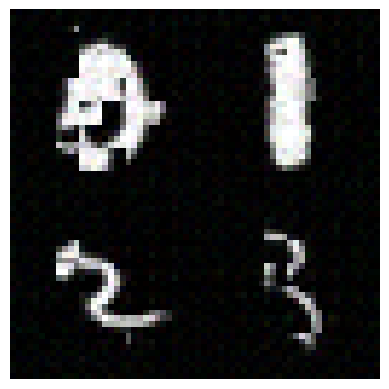

In [51]:
plt.imshow(samples_np)
plt.axis("off")
plt.show()

In [ ]:
def samples_con(con,vq_mean=vq_mean,vq_std=vq_std):

    con = con * vq_std + vq_mean  # 反归一化

    B, C, H, W = con.shape  
    con = con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=vae.decoder,
        latents=xT,
        y=con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    generation = euler_sampler(**sampling_kwargs_img).to(torch.float32)

    return generation


In [35]:
with torch.no_grad():
    # quant = euler_sampler(**sampling_kwargs_lat).to(torch.float32)
    # print("quant.shape",quant.shape)
    project_latents_con = project_latents * vq_std + vq_mean  # 反归一化

    B, C, H, W = project_latents_con.shape  
    project_latents_con = project_latents_con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=vae.decoder,
        latents=xT,
        y=project_latents_con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    project_latents_samples = euler_sampler(**sampling_kwargs_img).to(torch.float32)

samples = torch.clamp((project_latents_samples + 1) / 2, 0, 1)  # [-1, 1] → [0, 1]
samples_np = samples[0].permute(1, 2, 0).cpu().numpy()

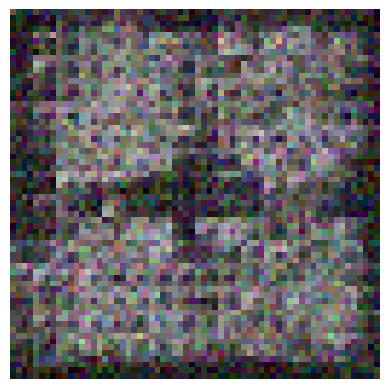

In [36]:
plt.imshow(samples_np)
plt.axis("off")
# plt.title("Generated Image")
# plt.savefig("/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png")
plt.show()

In [59]:
import os
import re
from PIL import Image
from torch.utils.data import Dataset, DataLoader, DistributedSampler
import torchvision.transforms as transforms
import torch
import random
from utils.data import random_crop_arr, center_crop_arr
transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: random_crop_arr(pil_image, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)
])
class DigitSeqDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.samples = []
        self.transform = transform
        for fname in os.listdir(image_dir):
            if fname.endswith(".png") and fname.startswith("seq_"):
                img_path = os.path.join(image_dir, fname)
                match = re.match(r"seq_(\d+)-(\d+)_\d+\.png", fname)
                if match:
                    digits = ",".join(str(d) for d in range(int(match[1]), int(match[2]) + 1))
                    prompt = f"An image of digits {digits}"
                    self.samples.append((img_path, prompt))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, text = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, text, img_path  # 返回 img_path 供后续 MLLM 加载原图


In [72]:
data_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images"
dataset = DigitSeqDataset(data_path, transform=transform)

train_loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)


In [82]:
def samples_con(con, xT, decoder, vq_mean=vq_mean, vq_std=vq_std):
    con = con * vq_std + vq_mean
    B, C, H, W = con.shape
    con = con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=decoder,
        latents=xT,
        y=con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    return euler_sampler(**sampling_kwargs_img).to(torch.float32)

In [83]:
import torch
import torch.nn as nn


class MLPProjector(nn.Module):
    def __init__(self, input_tokens=37, input_dim=3584, output_tokens=256, output_dim=32, hidden_dim=2048, depth=3):
        super().__init__()
        self.input_dim = input_dim
        self.input_tokens = input_tokens
        self.output_tokens = output_tokens
        self.output_dim = output_dim
        self.flatten_dim = input_tokens * input_dim
        self.output_flat_dim = output_tokens * output_dim

        layers = [nn.Linear(self.flatten_dim, hidden_dim)]
        for _ in range(1, depth):
            layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, self.output_flat_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, hidden_states):
        B, T, D = hidden_states.shape
        assert T == self.input_tokens and D == self.input_dim, \
            f"Expected input shape [B, {self.input_tokens}, {self.input_dim}], got [B, {T}, {D}]"
        x = hidden_states.view(B, -1)  # [B, 37*3584]
        x = self.mlp(x)                # [B, 256*32]
        x = x.view(B, self.output_tokens, self.output_dim)  # [B, 256, 32]
        return x



In [88]:
import torch.nn.functional as F 
from tqdm import trange
MLP = MLPProjector().to(device)
# 冻结 mllm_model 和 vae 的参数
for param in mllm_model.parameters():
    param.requires_grad = False

for param in vae.parameters():
    param.requires_grad = False

# Step 2: dummy 输入初始化 projector 参数（以当前 batch 的 token 数为准）
with torch.no_grad():
    dummy_hidden = torch.zeros(1, 37, 3584).to(device)  # or replace 366 with actual token count
    _ = MLP(dummy_hidden)

# Step 3: 创建优化器（此时 projector 已注册）
optimizer = torch.optim.Adam(MLP.parameters(), lr=1e-4)
resolution = 64
num_epochs = 10
weight = 1
for epoch in trange(num_epochs):
    for img_tensor, text_prompt, img_path in train_loader:
        xT = torch.randn(len(text_prompt), 3, resolution, resolution, device=device)
        # === Step 1: encode ground-truth latent ===
        img_tensor = img_tensor.to(device)  # shape [B, 3, 128, 128]
        with torch.no_grad():
            quant, _, _ = vae.encode(img_tensor)  # [B, 256, 32]
        print("quant:",quant.shape)
        print("text_prompt, img_path:",text_prompt, img_path)
        # === Step 2: get hidden_states from Qwen ===
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": p, "resized_height":resolution, "resized_width":resolution},
                    {"type": "text", "text": t}
                ]
            }
            for p, t in zip(img_path, text_prompt)
        ]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                           return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            outputs = mllm_model(**inputs, output_hidden_states=True, return_dict=True)
        hidden_states = outputs.hidden_states[-1].to(torch.float32)  # [B, T, D]
        print("hidden_states.shape:",hidden_states.shape)
        # === Step 3: project to latent space ===
        project_latents = MLP(hidden_states)  # [B, 32, 16, 16]
        B, N, C = quant.shape
        H = W = int(N**0.5)
        quant_input = quant.permute(0, 2, 1).view(B, C, H, W)  # [B, 32, 16, 16]
        print("quant_input:",quant_input.shape)
        project_latents_input = project_latents.permute(0, 2, 1).view(B, C, H, W)
        print("project_latents_input:",project_latents_input.shape)
        # === Step 4: compute loss ===
        semantic_loss = F.mse_loss(project_latents, quant.detach())
        with torch.no_grad():
            xT = torch.randn(B, 3, resolution, resolution, device=device)

        samples_real = samples_con(quant_input,xT,vae.decoder)  # [B, 3, H, W]
        samples_fake = samples_con(project_latents_input,xT,vae.decoder)

        pixel_loss = F.mse_loss(samples_fake, samples_real)

        total_loss = semantic_loss + weight * pixel_loss

        # === Step 5: backward ===
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"[Epoch {epoch}] semantic_loss: {semantic_loss.item():.4f}, pixel_loss: {pixel_loss.item():.4f}, total_loss: {total_loss.item():.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true

quant: torch.Size([1, 256, 32])
text_prompt, img_path: ['An image of digits 2,3,4,5'] ['/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images/seq_2-5_0752.png']
hidden_states.shape: torch.Size([1, 37, 3584])
quant_input: torch.Size([1, 32, 16, 16])
project_latents_input: torch.Size([1, 32, 16, 16])
quant: torch.Size([1, 256, 32])
text_prompt, img_path: ['An image of digits 5,6,7,8'] ['/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images/seq_5-8_0857.png']
hidden_states.shape: torch.Size([1, 37, 3584])
quant_input: torch.Size([1, 32, 16, 16])
project_latents_input: torch.Size([1, 32, 16, 16])
quant: torch.Size([1, 256, 32])
text_prompt, img_path: ['An image of digits 3,4,5,6'] ['/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images/seq_3-6_0903.png']
hidden_states.shape: torch.Size([1, 37, 3584])
quant_input: torch.Size([1, 32, 16, 16])
project_latents_input: torch.Size([1, 32, 16, 16])
quant: torch.Size([1, 256, 32])
text_prompt, img_path: ['An image of digi

  0%|          | 0/10 [00:45<?, ?it/s]


KeyboardInterrupt: 

In [1]:
import os
import re
from PIL import Image
from torch.utils.data import Dataset, DataLoader, DistributedSampler
import torchvision.transforms as transforms
import torch
import random
# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
from utils.data import random_crop_arr, center_crop_arr
import torch.nn.functional as F 
from tqdm import trange
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

# Minst-Mnist-JEPAAE
vae_config_path =  "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp006-aejepadiff-16.yaml"
vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp004-aejepadiff-16-jepa1.0-blocktyperandom/checkpoints/0001500.pt"
# sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mnist-mnist-seq-000-SiT-B-1-linear-uniform-0001500.pt-jepa1.0-blocktyperandom/checkpoints/0062000.pt"
vq_mean = 0.24468633210659027 
vq_std = 1.3076791763305664

model_name = "SiT-B/1"
num_classes =  1 #3
resolution = 64
path_type = "linear"
cfg_scale = 4.0
num_steps = 20
guidance_low = 0.0
guidance_high = 0.7

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

processor = AutoProcessor.from_pretrained(local_path)

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-16 21:23:02.623370: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 21:23:02.637373: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744809782.653426 1602017 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744809782.658047 1602017 cuda_blas.cc:1407] Un

Using device: cuda:1


Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  1.67it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [1]:
import os
import re
from PIL import Image
from torch.utils.data import Dataset, DataLoader, DistributedSampler
import torchvision.transforms as transforms
import torch
import random
# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
from utils.data import random_crop_arr, center_crop_arr
import torch.nn.functional as F 
from tqdm import trange


# --- 环境导入 ---
import sys
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
from modelling.sit import SiT_models
from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml

# Minst-Mnist-JEPAAE
vae_config_path =  "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp006-aejepadiff-16.yaml"
vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp004-aejepadiff-16-jepa1.0-blocktyperandom/checkpoints/0001500.pt"
sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mnist-mnist-seq-000-SiT-B-1-linear-uniform-0001500.pt-jepa1.0-blocktyperandom/checkpoints/0062000.pt"
vq_mean = 0.24468633210659027 
vq_std = 1.3076791763305664

model_name = "SiT-B/1"
num_classes =  1 #3
resolution = 64
path_type = "linear"
cfg_scale = 4.0
num_steps = 20
guidance_low = 0.0
guidance_high = 0.7

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")


block_kwargs = {"fused_attn": False, "flash_attn": True, "qk_norm": False}
model = SiT_models[model_name](
    in_channels=vae_embed_dim,
    input_size=dit_input_size,
    num_classes=num_classes,
    use_cfg=True,
    z_dims=[0],
    vae_1d=vae_1d,
    **block_kwargs,
)
state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']
model.load_state_dict(state_dict, strict=False)
model = model.to(device).eval()
print("Loaded SiT model.")

from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
# from transformers import AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

# local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/QVQ-72B-Preview"

# mllm_model = Qwen2VLForConditionalGeneration.from_pretrained(
#     local_path, torch_dtype="auto", device_map="auto"
# )

processor = AutoProcessor.from_pretrained(local_path)






transform = transforms.Compose([
    transforms.Lambda(lambda pil_image: random_crop_arr(pil_image, resolution)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)
])
class DigitSeqDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.samples = []
        self.transform = transform
        for fname in os.listdir(image_dir):
            if fname.endswith(".png") and fname.startswith("seq_"):
                img_path = os.path.join(image_dir, fname)
                match = re.match(r"seq_(\d+)-(\d+)_\d+\.png", fname)
                if match:
                    digits = ",".join(str(d) for d in range(int(match[1]), int(match[2]) + 1))
                    prompt = f"An image of digits {digits}"
                    self.samples.append((img_path, prompt))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, text = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, text, img_path  # 返回 img_path 供后续 MLLM 加载原图

data_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq/images"
dataset = DigitSeqDataset(data_path, transform=transform)

train_loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)

def samples_con(con, xT, decoder, vq_mean=vq_mean, vq_std=vq_std):
    con = con * vq_std + vq_mean
    B, C, H, W = con.shape
    con = con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=decoder,
        latents=xT,
        y=con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    return euler_sampler(**sampling_kwargs_img).to(torch.float32)

import torch
import torch.nn as nn


class MLPProjector(nn.Module):
    def __init__(self, input_tokens=37, input_dim=3584, output_tokens=256, output_dim=32, hidden_dim=2048, depth=3):
        super().__init__()
        self.input_dim = input_dim
        self.input_tokens = input_tokens
        self.output_tokens = output_tokens
        self.output_dim = output_dim
        self.flatten_dim = input_tokens * input_dim
        self.output_flat_dim = output_tokens * output_dim

        layers = [nn.Linear(self.flatten_dim, hidden_dim)]
        for _ in range(1, depth):
            layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, self.output_flat_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, hidden_states):
        B, T, D = hidden_states.shape
        assert T == self.input_tokens and D == self.input_dim, \
            f"Expected input shape [B, {self.input_tokens}, {self.input_dim}], got [B, {T}, {D}]"
        x = hidden_states.view(B, -1)  # [B, 37*3584]
        x = self.mlp(x)                # [B, 256*32]
        x = x.view(B, self.output_tokens, self.output_dim)  # [B, 256, 32]
        return x


MLP = MLPProjector().to(device)
# 冻结 mllm_model 和 vae 的参数
for param in mllm_model.parameters():
    param.requires_grad = False

for param in vae.parameters():
    param.requires_grad = False

# Step 2: dummy 输入初始化 projector 参数（以当前 batch 的 token 数为准）
with torch.no_grad():
    dummy_hidden = torch.zeros(1, 37, 3584).to(device)  # or replace 366 with actual token count
    _ = MLP(dummy_hidden)

# Step 3: 创建优化器（此时 projector 已注册）
optimizer = torch.optim.Adam(MLP.parameters(), lr=1e-4)
resolution = 64
num_epochs = 10
weight = 1
for epoch in trange(num_epochs):
    for img_tensor, text_prompt, img_path in train_loader:
        xT = torch.randn(len(text_prompt), 3, resolution, resolution, device=device)
        # === Step 1: encode ground-truth latent ===
        img_tensor = img_tensor.to(device)  # shape [B, 3, 128, 128]
        with torch.no_grad():
            quant, _, _ = vae.encode(img_tensor)  # [B, 256, 32]
        # print("quant:",quant.shape)
        # print("text_prompt, img_path:",text_prompt, img_path)
        # === Step 2: get hidden_states from Qwen ===
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": p, "resized_height":resolution, "resized_width":resolution},
                    {"type": "text", "text": t}
                ]
            }
            for p, t in zip(img_path, text_prompt)
        ]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = process_vision_info(messages)
        inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                           return_tensors="pt", padding=True).to(device)

        with torch.no_grad():
            outputs = mllm_model(**inputs, output_hidden_states=True, return_dict=True)
        hidden_states = outputs.hidden_states[-1].to(torch.float32)  # [B, T, D]
        # print("hidden_states.shape:",hidden_states.shape)
        # === Step 3: project to latent space ===
        project_latents = MLP(hidden_states)  # [B, 32, 16, 16]
        B, N, C = quant.shape
        H = W = int(N**0.5)
        quant_input = quant.permute(0, 2, 1).view(B, C, H, W)  # [B, 32, 16, 16]
        # print("quant_input:",quant_input.shape)
        project_latents_input = project_latents.permute(0, 2, 1).view(B, C, H, W)
        # print("project_latents_input:",project_latents_input.shape)
        # === Step 4: compute loss ===
        semantic_loss = F.mse_loss(project_latents, quant.detach())
        with torch.no_grad():
            xT = torch.randn(B, 3, resolution, resolution, device=device)

        samples_real = samples_con(quant_input,xT,vae.decoder)  # [B, 3, H, W]
        samples_fake = samples_con(project_latents_input,xT,vae.decoder)

        pixel_loss = F.mse_loss(samples_fake, samples_real)

        total_loss = semantic_loss + weight * pixel_loss

        # === Step 5: backward ===
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
    if epoch % 5 == 0:
        print(f"[Epoch {epoch}] semantic_loss: {semantic_loss.item():.4f}, pixel_loss: {pixel_loss.item():.4f}, total_loss: {total_loss.item():.4f}")

/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-16 21:32:44.813370: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 21:32:44.826980: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744810364.842735 2884543 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744810364.847314 2884543 cuda_blas.cc:1407] Un

Using device: cuda:1
<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False


/tmp/ipykernel_2884543/3345302869.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(sit_ckpt_path, map_location=device)['ema']


Loaded SiT model.


Loading checkpoint shards: 100%|██████████| 5/5 [00:03<00:00,  1.57it/s]
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.50, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
  0%|          | 0/10 [00:40<?, ?it/s]


KeyboardInterrupt: 

# Mask

In [19]:
import os
import re
from PIL import Image
from torch.utils.data import Dataset, DataLoader, DistributedSampler
import torchvision.transforms as transforms
import torch
import random
import torch
import torch.nn as nn
# --- 环境导入 ---
import sys
import wandb
sys.path.append('/cpfs04/user/hanyujin/rule-gen/rule_tokenizer')
import torch
# from modelling.sit import SiT_models
from modelling.lpips import LPIPS
# from modelling.tokenizer import SoftVQModel
from modelling.samplers import euler_sampler
from utils.model import build_tokenizer
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import ruamel.yaml as yaml
from utils.data import random_crop_arr, center_crop_arr
import torch.nn.functional as F 
from tqdm import trange, tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoTokenizer, AutoProcessor,Qwen2VLForConditionalGeneration
import numpy as np
from qwen_vl_utils import process_vision_info

# Minst-Mnist-JEPAAE

vae_type = 'AE'
model_name = "SiT-B/1"
num_classes =  1 #3
resolution = 64
path_type = "linear"
num_steps = 20
guidance_low = 0.0
guidance_high = 1.0
shuffle_ratio = 1
gpu_id = 1
resolution = 64
num_epochs = 1
recon_weight = 5
ori_weight  = 5
perceptual_loss_weight = 5
epoch_interval = 10
max_token = 25 #25 #37
input_dim = 3584
batch_size = 16
connector_type = 'mlp' # "transformer" # "Covntransformer" #'mlp'
device = torch.device(f"cuda:{gpu_id}" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if vae_type == 'JEPA-AE':
    vae_config_path =  "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp006-aejepadiff-16.yaml"
    vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp004-aejepadiff-16-jepa1.0-blocktyperandom/checkpoints/0001500.pt"
    # sit_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/sit/mnist-mnist-seq-000-SiT-B-1-linear-uniform-0001500.pt-jepa1.0-blocktyperandom/checkpoints/0062000.pt"
    vq_mean = 0.24468633210659027 
    vq_std = 1.3076791763305664
elif vae_type == 'AE':
    vae_config_path =  "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/configs/in1k/exp007-aediff-16.yaml"
    vae_ckpt_path = "/cpfs04/user/hanyujin/rule-gen/experiments/tokenizer/mnist-mnist-seq-exp003-aediff-16/checkpoints/0001500.pt"
    vq_mean = 0.07790039056539536
    vq_std = 0.9384990930557251

local_path = "/cpfs04/shared/CausaLLMs/HuggingfaceModels/Qwen2.5-VL-7B-Instruct"

mllm_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    local_path, torch_dtype="auto", device_map="auto"
)

processor = AutoProcessor.from_pretrained(local_path)

with open(vae_config_path, 'r') as f:
    config_args = yaml.YAML().load(f)
    dataset = config_args['dataset']
    vq_model = config_args['vq_model']

vae, vae_string_name, vae_embed_dim, dit_input_size, _, _, vae_1d = build_tokenizer(vae_config_path, vae_ckpt_path)
vae = vae.to(device).eval()
print(f"Loaded VAE: embed_dim={vae_embed_dim}, input_size={dit_input_size}, 1d={vae_1d}")


transform = transforms.Compose([
    # transforms.Lambda(lambda pil_image: random_crop_arr(pil_image, resolution)),
    transforms.Resize(resolution),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True)
])


class DigitSeqNegDataset(Dataset):
    def __init__(self, pos_dir, neg_dir, transform=None):
        self.samples = []
        self.transform = transform

        # 把 neg 中的图片放到字典中：编号后缀 → 文件名
        neg_dict = {
            re.search(r"_(\d{4})\.png", fname).group(1): fname
            for fname in os.listdir(neg_dir)
            if fname.endswith(".png")
        }

        for fname in os.listdir(pos_dir):
            if not fname.endswith(".png"):
                continue

            suffix_match = re.search(r"_(\d{4})\.png", fname)
            if not suffix_match:
                continue
            suffix = suffix_match.group(1)

            if suffix not in neg_dict:
                continue  

            pos_digits = list(map(int, re.search(r"mnist_(.*?)_\d{4}\.png", fname).group(1).split("-")))
            neg_fname = neg_dict[suffix]
            neg_digits = list(map(int, re.search(r"mnist_(.*?)_\d{4}\.png", neg_fname).group(1).split("-")))

            for i in range(4):
                if pos_digits[i] != neg_digits[i]:
                    changed_index = i
                    old_digit = neg_digits[i]
                    new_digit = pos_digits[i]
                    break

            region_names = ["top-left", "top-right", "bottom-left", "bottom-right"]
            # prompt = f"You should modify the image. Position: {region_names[changed_index]}. Modification: set the original digit to {new_digit}. Require: Keeping the rest of the image unchanged."
            prompt = f"An image of digits {pos_digits}."
            # prompt = f"An image of digits {neg_digits}."
            # prompt = f"The image shows four digits. The digit in the {region_names[changed_index]} corner is incorrect: it shows {old_digit}, but it should be {new_digit}. Please correct it."
            self.samples.append({
                "image_path_pos": os.path.join(pos_dir, fname),
                "image_path_neg": os.path.join(neg_dir, neg_fname),
                "prompt": prompt
            })
            # self.samples.append({
            #     "image_path_pos": os.path.join(pos_dir, fname),
            #     "image_path_neg": os.path.join(neg_dir, neg_fname),
            #     "prompt_new": prompt_new,
            #     "prompt_old": prompt_old
            # })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        entry = self.samples[idx]
        image_pos = Image.open(entry["image_path_pos"]).convert("RGB")
        image_neg = Image.open(entry["image_path_neg"]).convert("RGB")
        if self.transform:
            image_pos = self.transform(image_pos)
            image_neg = self.transform(image_neg)
        # return image_pos, entry["prompt_new"], entry["prompt_old"], entry["image_path_neg"], image_neg
        return image_pos, entry["prompt"], entry["image_path_neg"], image_neg


data_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-pos/images"
data_path_neg = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images"

dataset = DigitSeqNegDataset(
    pos_dir = data_path,
    neg_dir = data_path_neg,
    transform=transform
)

train_loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True,
)

def samples_con(con, xT, decoder, vq_mean=vq_mean, vq_std=vq_std):
    con = con * vq_std + vq_mean
    B, C, H, W = con.shape
    con = con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=decoder,
        latents=xT,
        y=con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    return euler_sampler(**sampling_kwargs_img).to(torch.float32)


class MLPProjector(nn.Module):
    def __init__(self, input_tokens=1, input_dim=input_dim, output_tokens=256, output_dim=32, hidden_dim=2048, depth=2): #if full last layer set input_tokens=max_token
        super().__init__()
        self.input_dim = input_dim
        self.input_tokens = input_tokens
        self.output_tokens = output_tokens
        self.output_dim = output_dim
        self.flatten_dim = input_tokens * input_dim
        self.output_flat_dim = output_tokens * output_dim

        layers = [nn.Linear(self.flatten_dim, hidden_dim)]
        for _ in range(1, depth):
            layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, self.output_flat_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, hidden_states):
        # B, T, D = hidden_states.shape
        # assert T == self.input_tokens and D == self.input_dim, \
        #     f"Expected input shape [B, {self.input_tokens}, {self.input_dim}], got [B, {T}, {D}]"
        B, _ = hidden_states.shape
        x = hidden_states.view(B, -1)  # [B, 37*3584]
        x = self.mlp(x)                # [B, 256*32]
        x = x.view(B, self.output_tokens, self.output_dim)  # [B, 256, 32]
        return x




if connector_type == "mlp":
    connector = MLPProjector().to(device)
print(f"The connector is {connector_type}")
# 冻结 mllm_model 和 vae 的参数
for param in mllm_model.parameters():
    param.requires_grad = False

for param in vae.parameters():
    param.requires_grad = False




optimizer = torch.optim.Adam(connector.parameters(), lr=1e-4)

global_step = 0

if perceptual_loss_weight > 0:
    lpips_loss = LPIPS().eval().to(device)

for epoch in trange(num_epochs):
    for img_tensor, text_prompt, img_path, img_neg in tqdm(train_loader, desc=f"Epoch {epoch}"):
        B = len(text_prompt)
        xT = torch.randn(B, 3, resolution, resolution, device=device)

        # === Step 1: encode ground-truth latent ===
        img_tensor = img_tensor.to(device)  # [B, 3, H, W]
        img_neg = img_neg.to(device)  # [B, 3, H, W]
        with torch.no_grad():
            quant, _, _ = vae.encode(img_tensor)  # [B, 256, 32]
            quant_neg, _, _ = vae.encode(img_neg)

        # === Step 2: 构造 Qwen2.5-VL 输入 ===
        messages_list = [
            [{
                "role": "user",
                "content": [
                    {"type": "image", "image": img_path[i]},
                    {"type": "text", "text": text_prompt[i]}
                ]
            }] for i in range(B)
        ]
        texts = [
            processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
            for msg in messages_list
        ]
        image_inputs, video_inputs = process_vision_info([m[0] for m in messages_list])

        inputs = processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = mllm_model(**inputs, output_hidden_states=True, output_attentions=True, return_dict=True)
        hidden_states = outputs.hidden_states[-1][:, -1, :].to(torch.float32)  # [B, max_token, 3584]
        # print("hidden_states:",hidden_states.shape)
        
        # === Step 3: project to latent space ===
        project_latents = connector(hidden_states)  # [B, 256, 32]

        # === Step 4: compute loss ===
        B, N, C = quant.shape
        H = W = int(N ** 0.5)
        quant_input = quant.permute(0, 2, 1).view(B, C, H, W)  # [B, 32, 16, 16]
        project_latents_input = project_latents.permute(0, 2, 1).view(B, C, H, W)

        semantic_loss = F.mse_loss(project_latents, quant.detach())

        samples_real = samples_con(quant_input, xT, vae.decoder)
        samples_fake = samples_con(project_latents_input, xT, vae.decoder)
        print(f"[semantic_loss: {semantic_loss.item():.4f}, recon_pixel_loss: {recon_pixel_loss.item():.4f}, ori_pixel_loss: {ori_pixel_loss.item():.4f}, total_loss: {total_loss.item():.4f}")
        recon_pixel_loss = F.mse_loss(samples_fake, samples_real)
        ori_pixel_loss = F.mse_loss(samples_fake, img_tensor)
        # print(f"[semantic_loss: {semantic_loss.item():.4f}, recon_pixel_loss: {recon_pixel_loss.item():.4f}, ori_pixel_loss: {ori_pixel_loss.item():.4f}, total_loss: {total_loss.item():.4f}")

        if perceptual_loss_weight > 0:
            ori_perceptual_loss = lpips_loss(img_tensor, samples_fake).mean()
        else:
            ori_perceptual_loss = torch.tensor(0., device=img_tensor.device, dtype=img_tensor.dtype)


        total_loss = semantic_loss + recon_weight * recon_pixel_loss + ori_weight * ori_pixel_loss + perceptual_loss_weight * ori_perceptual_loss

        # === Step 5: backward ===
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        global_step += 1




    # === 保存 checkpoint ===
    if epoch % epoch_interval == 0:
        print(f"[Epoch {epoch}] semantic_loss: {semantic_loss.item():.4f}, recon_pixel_loss: {recon_pixel_loss.item():.4f}, ori_pixel_loss: {ori_pixel_loss.item():.4f}, total_loss: {total_loss.item():.4f}")

Using device: cuda:1


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

<All keys matched successfully>
Loaded VAE: embed_dim=32, input_size=16, 1d=False
The connector is mlp


/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/yjenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/modelling/lpips/lpips.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/py

loaded pretrained LPIPS loss from /cpfs04/user/hanyujin/rule-gen/rule_tokenizer/modelling/lpips/cache/vgg.pth


  0%|          | 0/1 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true 

NameError: name 'recon_pixel_loss' is not defined

You should modify the image. Position: top-left. Modification: set the original digit to 6. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_1-7-8-9_0920.png


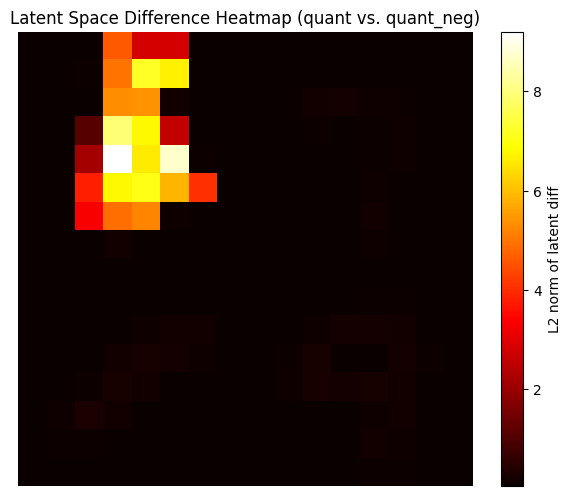

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

j = 13
# 选取第一个样本并 reshape 为 [1, 16, 16, 32]
q = quant[j].view(16, 16, 32)
q_neg = quant_neg[j].view(16, 16, 32)
print(text_prompt[j])
print(img_path[j])
# 差值并取 L2 norm
diff = q - q_neg
diff_norm = torch.norm(diff, dim=-1).cpu().numpy()  # shape: [16, 16]

# 可视化热力图
plt.figure(figsize=(6, 5))
plt.imshow(diff_norm, cmap="hot", interpolation="nearest")
plt.colorbar(label="L2 norm of latent diff")
plt.title("Latent Space Difference Heatmap (quant vs. quant_neg)")
plt.axis("off")
plt.tight_layout()
plt.show()


In [45]:
mllm_model

Qwen2_5_VLForConditionalGeneration(
  (visual): Qwen2_5_VisionTransformerPretrainedModel(
    (patch_embed): Qwen2_5_VisionPatchEmbed(
      (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
    )
    (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
    (blocks): ModuleList(
      (0-31): 32 x Qwen2_5_VLVisionBlock(
        (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
        (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
        (attn): Qwen2_5_VLVisionSdpaAttention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (mlp): Qwen2_5_VLMLP(
          (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
          (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
          (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
          (act_fn): SiLU()
        )
      )
    )
    (merger): Qwen2_5_VLPatchMerger

In [3]:
attentions = outputs.attentions

In [4]:
attentions[1].shape

torch.Size([16, 28, 56, 56])

In [ ]:
from transformers import AutoTokenizer

tokenizer = processor.tokenizer

prompt = text_prompt[j]

# 1. Token string
tokens = tokenizer.tokenize(prompt)
print("🔤 Tokens:", tokens)

# 2. 对关键词也 tokenize 一下
start_phrase = " Position:"
end_phrase = " Modification:"
start_tokens = tokenizer.tokenize(start_phrase)
end_tokens = tokenizer.tokenize(end_phrase)
print("🔍 Start phrase tokens:", start_tokens)
print("🔍 End phrase tokens:", end_tokens)

# 3. 将 token → ID，确认是否存在
input_ids = tokenizer(prompt)["input_ids"]
start_ids = tokenizer(start_phrase)["input_ids"][1:-1]  # 去掉BOS和EOS
end_ids = tokenizer(end_phrase)["input_ids"][1:-1]

print("📟 Input IDs:", input_ids)
print("📟 Start IDs:", start_ids)
print("📟 End IDs:", end_ids)

# 4. 用 string token match 寻找 span 最稳定
def find_sublist_index(sublist, full_list):
    for i in range(len(full_list) - len(sublist) + 1):
        if full_list[i:i+len(sublist)] == sublist:
            return i
    return -1

start_idx = find_sublist_index(start_tokens, tokens)
end_idx = find_sublist_index(end_tokens, tokens)

print(f"📌 位置信息 token span: {start_idx + len(start_tokens)} 到 {end_idx}")


🔤 Tokens: ['You', 'Ġshould', 'Ġmodify', 'Ġthe', 'Ġimage', '.', 'ĠPosition', ':', 'Ġtop', '-left', '.', 'ĠModification', ':', 'Ġset', 'Ġthe', 'Ġoriginal', 'Ġdigit', 'Ġto', 'Ġ', '6', '.', 'ĠRequire', ':', 'ĠKeeping', 'Ġthe', 'Ġrest', 'Ġof', 'Ġthe', 'Ġimage', 'Ġunchanged', '.']
🔍 Start phrase tokens: ['ĠPosition', ':']
🔍 End phrase tokens: ['ĠModification', ':']
📟 Input IDs: [2610, 1265, 5602, 279, 2168, 13, 12380, 25, 1909, 7950, 13, 73855, 25, 738, 279, 4024, 15723, 311, 220, 21, 13, 24046, 25, 55378, 279, 2732, 315, 279, 2168, 34857, 13]
📟 Start IDs: []
📟 End IDs: []
📌 位置信息 token span: 8 到 11


In [16]:
# 假设你想取 decoder 最后一层（或者其他层）
position_tokens = input_ids[start_idx + len(start_tokens):end_idx]
last_attn = outputs.attentions[-1][j] # [B, num_heads, T, T]
attn_avg = last_attn.mean(dim=1)

In [20]:
messages_list = [
    [{
        "role": "user",
        "content": [
            {"type": "image", "image": img_path[i]},
            {"type": "text", "text": text_prompt[i]}
        ]
    }] for i in range(B)
]
texts = [
    processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
    for msg in messages_list
]
image_inputs, video_inputs = process_vision_info([m[0] for m in messages_list])

inputs = processor(
    text=texts,
    images=image_inputs,
    videos=video_inputs,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = mllm_model(**inputs, output_hidden_states=True, output_attentions=True, return_dict=True)
hidden_states = outputs.hidden_states[-1][:, -1, :].to(torch.float32)  # [B, max_token, 3584]

In [27]:
text_prompt[0]

'An image of digits [5, 6, 7, 8].'

In [55]:
messages_base = [
    [{
        "role": "user",
        "content": [
            {"type": "image", "image": img_path[i]},
            {"type": "text", "text": ''}
        ]
    }] for i in range(B)
]
texts_base = [
    processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
    for msg in messages_base
]
image_inputs, video_inputs = process_vision_info([m[0] for m in messages_base])

inputs_base = processor(
    text=texts_base,
    images=image_inputs,
    videos=video_inputs,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs_base = mllm_model(**inputs_base, output_hidden_states=True, output_attentions=True, return_dict=True)
hidden_states_base = outputs_base.hidden_states[-1][:, -1, :].to(torch.float32)  # [B, max_token, 3584]

In [56]:
import torch

# 差值张量
diff = hidden_states[0] - hidden_states_base[0]  # [T, D]

# 非零元素个数
nonzero_count = (diff != 0).sum().item()

# 总元素个数
total_elements = diff.numel()

# 占比
ratio = nonzero_count / total_elements

print(f"🧮 非零元素数量: {nonzero_count} / {total_elements}")
print(f"📊 占比: {ratio:.4%}")
(hidden_states[0] - hidden_states_base[0])

🧮 非零元素数量: 3579 / 3584
📊 占比: 99.8605%


tensor([ 1.3125, -5.0845,  2.1562,  ..., -6.2109, -0.6406,  3.1641],
       device='cuda:1')

In [21]:
class MLPProjector(nn.Module):
    def __init__(self, input_tokens=1, input_dim=input_dim, output_tokens=256, output_dim=32, hidden_dim=2048, depth=2): #if full last layer set input_tokens=max_token
        super().__init__()
        self.input_dim = input_dim
        self.input_tokens = input_tokens
        self.output_tokens = output_tokens
        self.output_dim = output_dim
        self.flatten_dim = input_tokens * input_dim
        self.output_flat_dim = output_tokens * output_dim

        layers = [nn.Linear(self.flatten_dim, hidden_dim)]
        for _ in range(1, depth):
            layers.append(nn.GELU())
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        layers.append(nn.GELU())
        layers.append(nn.Linear(hidden_dim, self.output_flat_dim))

        self.mlp = nn.Sequential(*layers)

    def forward(self, hidden_states):
        # B, T, D = hidden_states.shape
        # assert T == self.input_tokens and D == self.input_dim, \
        #     f"Expected input shape [B, {self.input_tokens}, {self.input_dim}], got [B, {T}, {D}]"
        B, _ = hidden_states.shape
        x = hidden_states.view(B, -1)  # [B, 37*3584]
        x = self.mlp(x)                # [B, 256*32]
        x = x.view(B, self.output_tokens, self.output_dim)  # [B, 256, 32]
        return x

connector = MLPProjector().to(device)

# # 加载权重
ckpt_path = "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/connector/checkpoints/AE-connectormlp_weight5-ori_weight5-perceptual5_shuffle1-lastoken/epoch160.pt"
state_dict = torch.load(ckpt_path, map_location=device)

# 如果之前是多卡保存的，需要去掉 'module.' 前缀
if any(k.startswith("module.") for k in state_dict.keys()):
    state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}

# 加载模型参数
connector.load_state_dict(state_dict)

print("✅ 权重加载成功！")

✅ 权重加载成功！


/tmp/ipykernel_1220971/3438912187.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(ckpt_path, map_location=device)


In [ ]:
(hidden_states[-1][:, -1, :]).to(torch.float32)  # [B, max_token, D]
#         

In [22]:
project_latents = connector(hidden_states)
# project_latents_base = connector(hidden_states_base)

In [23]:
def samples_con(con, xT, decoder, vq_mean=vq_mean, vq_std=vq_std):
    con = con * vq_std + vq_mean
    B, C, H, W = con.shape
    con = con.view(B, C, H * W).permute(0, 2, 1)

    sampling_kwargs_img = dict(
        model=decoder,
        latents=xT,
        y=con,
        num_steps=num_steps,
        heun=False,
        cfg_scale=1,
        guidance_low=guidance_low,
        guidance_high=guidance_high,
        path_type=path_type,
        num_classes=num_classes
    )
    return euler_sampler(**sampling_kwargs_img).to(torch.float32)

In [24]:
B, N, C = project_latents.shape
H = W = int(N ** 0.5)
project_latents_input = project_latents.permute(0, 2, 1).view(B, C, H, W)
# project_latents_base_input = project_latents_base.permute(0, 2, 1).view(B, C, H, W)
samples = samples_con(project_latents_input, xT, vae.decoder)
# samples_base = samples_con(project_latents_base_input, xT, vae.decoder)

In [25]:
samples.shape

torch.Size([16, 3, 64, 64])

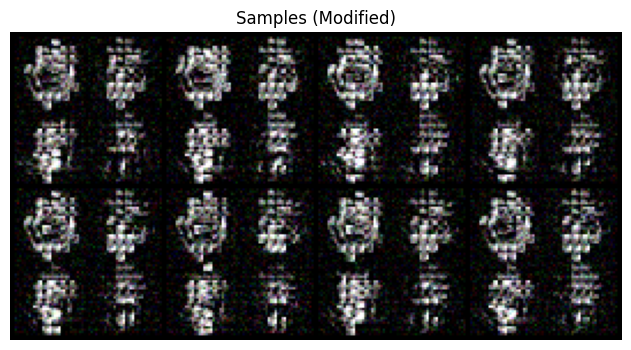

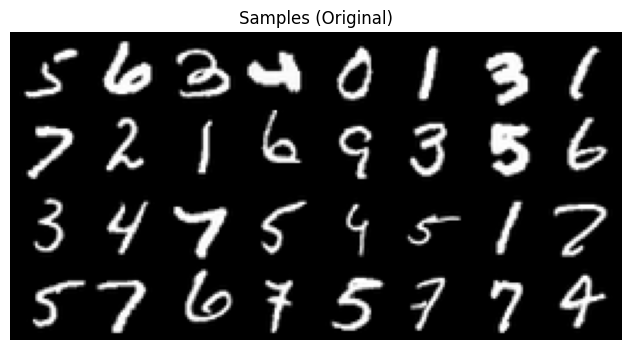

In [26]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

def show_image_grid(tensor_batch, title):
    # 对每张图像做 ((x.clamp(-1, 1) + 1) / 2)
    normed = torch.stack([(img.clamp(-1, 1) + 1) / 2 for img in tensor_batch])  # shape: [B, 3, 64, 64]

    grid_img = make_grid(normed, nrow=4)  # value_range 已处理
    plt.figure(figsize=(8, 4))
    plt.imshow(to_pil_image(grid_img))
    plt.title(title)
    plt.axis("off")
    plt.show()

# 示例使用
show_image_grid(samples[:8], "Samples (Modified)")
show_image_grid(img_neg[:8], "Samples (Original)")


In [ ]:
for i in range(len(img_path)):
    print(img_path[i])
    print(text_prompt[i])

/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_4-5-1-7_0627.png
You should modify the image. Position: bottom-left. Modification: set the original digit to 6. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_9-1-2-3_0056.png
You should modify the image. Position: top-left. Modification: set the original digit to 0. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_3-5-6-7_0728.png
You should modify the image. Position: top-left. Modification: set the original digit to 4. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_0-1-2-9_0116.png
You should modify the image. Position: bottom-right. Modification: set the original digit to 3. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-n

/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_4-5-1-7_0627.png
You should modify the image. Position: bottom-left. Modification: set the original digit to 6. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_9-1-2-3_0056.png
You should modify the image. Position: top-left. Modification: set the original digit to 0. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_3-5-6-7_0728.png
You should modify the image. Position: top-left. Modification: set the original digit to 4. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_0-1-2-9_0116.png
You should modify the image. Position: bottom-right. Modification: set the original digit to 3. Require: Keeping the rest of the image unchanged.
/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-n

In [96]:
# Normalized 
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import re
from transformers import AutoTokenizer

image_path = "/cpfs04/user/hanyujin/rule-gen/datasets/mnist-mnist-seq-neg-1/images/mnist_4-5-1-7_0627.png"
text = "You should modify the image. Position: top-left. Modification: set the original digit to 0. Require: Keeping the rest of the image unchanged."
# "/cpfs04/user/hanyujin/rule-gen/rule_tokenizer/inference/test_img/test.png"
image_size = 64
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
            text
            )},
        ],
    }
]

# Preparation for inference
text = processor.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")


# ✅ 4. 启用梯度计算，重新 forward 计算 logits
inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
# input_len = inputs['input_ids'].shape[1]
# logits = mllm_model(**inputs, output_hidden_states=False).logits
# zero_logit = logits[:, input_len, :]  # 取第一个生成 token 的 logits
zero_logit = mllm_model(**inputs, output_hidden_states=False).logits[:, -1, :]
true_class = torch.argmax(zero_logit, dim=1)

# 计算 CrossEntropy Loss
criterion = nn.CrossEntropyLoss()
loss = -criterion(zero_logit, true_class)

# 计算 grads
grads = torch.autograd.grad(loss, inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
token_grid_size = int(np.sqrt(grads.shape[0]))  # 计算 token grid 的大小
grads = grads[:token_grid_size**2, :].view(token_grid_size, token_grid_size, -1)
print(f"Reshaped grads shape: {grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
grad_norm = torch.norm(grads, dim=-1).detach().cpu().numpy()
print(f"Grad norm shape: {grad_norm.shape}")  # [18, 18]

## General
general_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image_path,"resized_height":image_size,"resized_width":image_size},
            {"type": "text", "text": (
                ""
                # "Write a general description of the image."
            )},
        ],
    }
]

# Preparation for inference
general_text = processor.apply_chat_template(
    general_messages, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(general_messages)
general_inputs = processor(
    text=[general_text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
general_inputs = general_inputs.to("cuda")

general_inputs['pixel_values'].requires_grad = True  # 重新启用梯度
# 启用梯度计算，重新获取 logits 计算梯度
# general_input_len = general_inputs['input_ids'].shape[1]
# general_logits = mllm_model(**general_inputs, output_hidden_states=False).logits
# general_zero_logit = general_logits[:, general_input_len, :]  # 取第一个生成 token 的 logits
general_zero_logit = mllm_model(**general_inputs, output_hidden_states=False).logits[:, -1, :]
general_true_class = torch.argmax(general_zero_logit, dim=1)
print("general_true_class:",general_true_class)
general_loss = -criterion(general_zero_logit, general_true_class)

# 计算 grads
general_grads = torch.autograd.grad(general_loss, general_inputs['pixel_values'], retain_graph=True)[0]
print(f"Grads shape: {general_grads.shape}")  # 应该是 [324, 1176] 或其他

# 重新 reshape grads
general_token_grid_size = int(np.sqrt(general_grads.shape[0]))  # 计算 token grid 的大小
general_grads = general_grads[:general_token_grid_size**2, :].view(general_token_grid_size, general_token_grid_size, -1)
print(f"General Reshaped grads shape: {general_grads.shape}")  # [18, 18, 1176]

# 计算 grads 的范数
general_grad_norm = torch.norm(general_grads, dim=-1).detach().cpu().numpy()
print(f"General Grad norm shape: {general_grad_norm.shape}")  # [18, 18]

grad_norm_norm = grad_norm / general_grad_norm

Grads shape: torch.Size([16, 1176])
Reshaped grads shape: torch.Size([4, 4, 1176])
Grad norm shape: (4, 4)
general_true_class: tensor([785], device='cuda:0')
Grads shape: torch.Size([16, 1176])
General Reshaped grads shape: torch.Size([4, 4, 1176])
General Grad norm shape: (4, 4)


In [97]:
def visualize_token_grads_from_heatmap(grad_norm_map, image_size=(64, 64), title="Token Grad Ratio Heatmap"):
    """
    grad_norm_map: torch.Tensor or np.ndarray of shape [H, W]
    This function assumes you have already computed the token-level heatmap (e.g., grad_norm / general_grad_norm)
    and just want to upsample + visualize it.
    """
    import torch
    import torch.nn.functional as F
    import matplotlib.pyplot as plt

    # Ensure tensor
    if isinstance(grad_norm_map, np.ndarray):
        grad_norm_map = torch.from_numpy(grad_norm_map)

    grad_norm_map = grad_norm_map.float().unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]

    # Interpolate to image size
    grad_interp = F.interpolate(grad_norm_map, size=image_size, mode='bilinear', align_corners=False)

    # 可视化
    plt.imshow(grad_interp[0, 0].cpu().numpy(), cmap='viridis')
    plt.title(title)
    plt.colorbar()
    plt.axis('off')
    plt.show()

    return grad_interp  # shape: [1, 1, H, W]


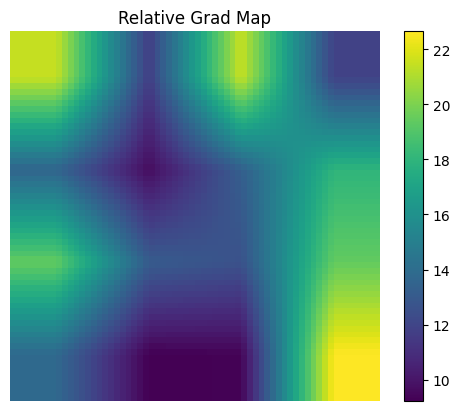

tensor([[[[21.4913, 21.4913, 21.4913,  ..., 11.8846, 11.8846, 11.8846],
          [21.4913, 21.4913, 21.4913,  ..., 11.8846, 11.8846, 11.8846],
          [21.4913, 21.4913, 21.4913,  ..., 11.8846, 11.8846, 11.8846],
          ...,
          [13.7903, 13.7903, 13.7903,  ..., 22.6453, 22.6453, 22.6453],
          [13.7903, 13.7903, 13.7903,  ..., 22.6453, 22.6453, 22.6453],
          [13.7903, 13.7903, 13.7903,  ..., 22.6453, 22.6453, 22.6453]]]])

In [98]:
visualize_token_grads_from_heatmap(grad_norm_norm, image_size=(64, 64), title="Relative Grad Map")